In [1]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import S0, K, T, r, sigma
from black_scholes import prix_call_black_scholes
from monte_carlo import prix_call_monte_carlo

In [2]:
N_valeurs = [100, 1000, 10000, 100000]

prix_bs = prix_call_black_scholes(S0, K, T, r, sigma)

resultats_mc = []
erreurs = []

for N in N_valeurs:
    prix_mc = prix_call_monte_carlo(S0, K, T, r, sigma, N)
    erreur = abs(prix_mc - prix_bs)
    
    resultats_mc.append(prix_mc)
    erreurs.append(erreur)

df_comparaison = pd.DataFrame({
    'N (Simulations)': N_valeurs,
    'Prix Monte-Carlo (€)': resultats_mc,
    'Erreur Absolue (€)': erreurs
})

print(f"Prix théorique Black-Scholes : {prix_bs:.4f} €\n")
display(df_comparaison)

Prix théorique Black-Scholes : 4.5817 €



,N (Simulations),Prix Monte-Carlo (€),Erreur Absolue (€)
0,100,6.144967,1.563287
1,1000,4.826688,0.245008
2,10000,4.640643,0.058963
3,100000,4.600983,0.019303


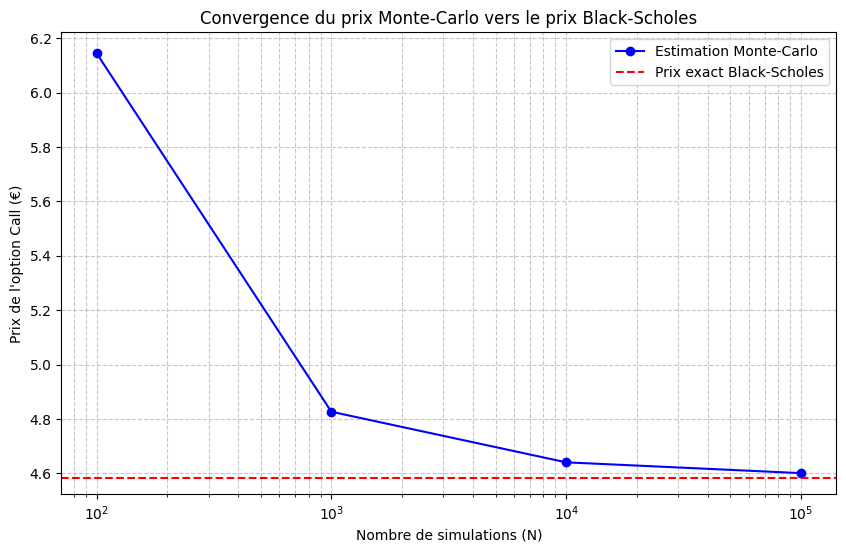

In [3]:
plt.figure(figsize=(10, 6))

plt.plot(N_valeurs, resultats_mc, marker='o', linestyle='-', color='blue', label='Estimation Monte-Carlo')
plt.axhline(y=prix_bs, color='red', linestyle='--', label='Prix exact Black-Scholes')

plt.xscale('log')
plt.xlabel('Nombre de simulations (N)')
plt.ylabel("Prix de l'option Call (€)")
plt.title("Convergence du prix Monte-Carlo vers le prix Black-Scholes")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.7)

plt.show()